<a href="https://colab.research.google.com/github/umair594/Data-Science_Projects/blob/main/YouTube_Data_Scraping%2C_Preprocessing_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **YouTube Data Scraping, Preprocessing and Analysis using Python**

YouTube is one of the largest video-sharing platforms, hosting millions of videos across diverse categories and audiences. Analyzing YouTube data helps uncover valuable insights about content performance, viewer engagement and emerging trends. In this article, we will use real YouTube channel data to extract meaningful patterns and visualise key metrics effectively using Python.

# **Web Scraping**

Web scraping is the process of automatically extracting data from websites. Here we focus on scraping YouTube video data using Python tools like requests and BeautifulSoup, which allows us to collect information such as video titles, views and upload dates for analysis or research purposes.

# **1. Installing Required Libraries**

**Here we install requests, beautifulsoup4 and xlsxwriter**

In [1]:
!pip install requests beautifulsoup4 xlsxwriter --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.3 MB/s eta 0:00:00


# **2. Importing Libraries**

Libraries for sending HTTP requests, parsing HTML content, handling JSON data and writing Excel files are imported to support the scraping pipeline.

In [2]:
import requests
from bs4 import BeautifulSoup
import json
import xlsxwriter

# **3. Sending HTTP Request to YouTube Page**

An HTTP request is sent to the YouTube channel’s videos page. A User-Agent header is included to mimic a real browser and avoid request blocking.

**Here we will be using:** https://www.youtube.com/c/GeeksforGeeksVideos/videos

In [3]:
url = "https://www.youtube.com/c/GeeksforGeeksVideos/videos"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
html = response.text

# **4. Creating the BeautifulSoup Object**

The HTML response obtained from the request is parsed using BeautifulSoup. This allows structured navigation through the page and easy extraction of required elements.

In [4]:
soup = BeautifulSoup(html, "html.parser")

# **5. Extracting Embedded YouTube JSON Data**

YouTube loads video data dynamically using JavaScript. The embedded ytInitialData JSON is extracted from the page source to access structured video information.

In [5]:
script_tag = soup.find("script", text=lambda t: t and "var ytInitialData = " in t)
json_text = script_tag.string.strip()[len("var ytInitialData = "):-1]
data = json.loads(json_text)

/tmp/ipykernel_1063/3690196292.py:1: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  script_tag = soup.find("script", text=lambda t: t and "var ytInitialData = " in t)


# **6. Navigating to Video Metadata**

The nested JSON structure is traversed to locate the section containing individual video metadata. This includes information such as video title, view count and duration.

In [6]:
videos_data = data['contents']['twoColumnBrowseResultsRenderer']['tabs'][1]\
              ['tabRenderer']['content']['richGridRenderer']['contents']

# **7. Extracting Titles, Views and Durations**

Each video entry is processed in a loop to extract relevant fields safely. The extraction is limited to the most recent 30 videos to keep the dataset manageable.

In [8]:
titles, views, durations = [], [], []
count = 0

for item in videos_data:
    try:
        video = item['richItemRenderer']['content']['videoRenderer']
        titles.append(video['title']['runs'][0]['text'])
        views.append(video.get('viewCountText', {}).get('simpleText', 'N/A'))
        durations.append(video.get('lengthText', {}).get('simpleText', 'N/A'))
        count += 1
        if count >= 30:
            break
    except:
        continue

# **8. Creating the Excel File**

An Excel workbook and worksheet are created using XLSXWriter. Column headers are added to clearly represent each extracted data attribute.

In [9]:
workbook = xlsxwriter.Workbook("youtube_videos.xlsx")
sheet = workbook.add_worksheet()

sheet.write(0, 0, "Title")
sheet.write(0, 1, "Views")
sheet.write(0, 2, "Duration")

0

# **9. Writing Data to Excel Sheet**

The extracted video data is written row-by-row into the Excel sheet. This ensures that each video details are stored in a structured tabular format.

In [10]:
for i in range(len(titles)):
    sheet.write(i+1, 0, titles[i])
    sheet.write(i+1, 1, views[i])
    sheet.write(i+1, 2, durations[i])

# **10. Saving the File**

The workbook is closed to save the Excel file properly. This completes the web scraping process and stores the data for further analysis.

In [11]:
workbook.close()
print("Scraped latest 30 videos successfully! Saved as youtube_videos.xlsx")

Scraped latest 30 videos successfully! Saved as youtube_videos.xlsx


**Output:**

Scraped latest 30 videos successfully! Saved as youtube_videos.xlsx

# **Data Preprocessing**

Scraped data often contains text-based values and inconsistencies. Data preprocessing cleans and standardizes the data to make it suitable for analysis and visualization.

# **1. Importing the Data**

The scraped Excel file is loaded into a pandas DataFrame. This allows efficient data manipulation and preprocessing operations.

In [12]:
import pandas as pd

data = pd.read_excel("youtube_videos.xlsx")
data.head()

,Title,Views,Duration
0,Are You Making These Mistakes In Your Tech Int...,"1,183 views",2:22
1,Have you been learning tech the wrong way?,"1,290 views",4:35
2,Industry Layoffs Are Back 😨 | What It Means fo...,"4,865 views",5:20
3,Hard Truth of FDE | Reality of Software Develo...,"1,146 views",7:38
4,What is Vibe Coding? | Vibe Coding Explained |...,992 views,25:45


# **2. Cleaning the Views Column**

The Views column contains textual information. First the views suffix is removed. Then views are converted to numeric values:

Removing the views suffix.

Converting values ending with K to numeric by multiplying by 1000.

Converting plain numeric strings to floats.

Setting any inconsistent or missing entries to None

In [13]:
data['Views'] = data['Views'].str.replace(" views", "", regex=False).str.strip()
cleaned_views = []
for i in data['Views']:
    if pd.isna(i):
        cleaned_views.append(None)
        continue

    i = str(i).replace(",", "")

    if i.endswith('K') or i.endswith('k'):
        i = i.replace('K', '').replace('k', '')
        try:
            cleaned_views.append(float(i) * 1000)
        except:
            cleaned_views.append(None)
    else:
        try:
            cleaned_views.append(float(i))
        except:
            cleaned_views.append(None)

data['Views'] = cleaned_views

# **3. Cleaning the Duration Column**

**Here we:**

Removes newline characters.
Converts durations to total seconds.
Sets invalid or missing entries to None.

In [14]:
data['Duration'] = data['Duration'].str.replace("\n", "", regex=False)
def duration_to_seconds(duration_str):
    if pd.isna(duration_str) or duration_str in ['SHORTS', 'N/A']:
        return None
    parts = str(duration_str).split(':')
    if len(parts) == 3:
        h, m, s = map(int, parts)
        return h * 3600 + m * 60 + s
    elif len(parts) == 2:
        m, s = map(int, parts)
        return m * 60 + s
    return None

data['Duration'] = data['Duration'].apply(duration_to_seconds)

# **4. Categorizing Videos by Duration**

Videos are grouped into categories based on their duration. This simplifies analysis and helps compare different types of content.

In [15]:
for i in data.index:
    val = data.loc[i, 'Duration']

    if val is None:
        continue
    elif val < 900:
        data.loc[i, 'Duration'] = 'Mini-Videos'
    elif val < 3600:
        data.loc[i, 'Duration'] = 'Long-Videos'
    else:
        data.loc[i, 'Duration'] = 'Very-Long-Videos'

data.head()

/tmp/ipykernel_1063/4002048857.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Mini-Videos' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[i, 'Duration'] = 'Mini-Videos'


,Title,Views,Duration
0,Are You Making These Mistakes In Your Tech Int...,1183.0,Mini-Videos
1,Have you been learning tech the wrong way?,1290.0,Mini-Videos
2,Industry Layoffs Are Back 😨 | What It Means fo...,4865.0,Mini-Videos
3,Hard Truth of FDE | Reality of Software Develo...,1146.0,Mini-Videos
4,What is Vibe Coding? | Vibe Coding Explained |...,992.0,Long-Videos


# **Text Preprocessing**

This is an important step in preparing textual data such as video titles, for tasks like text analysis, sentiment analysis or machine learning models. Preprocessing ensures that the text is normalized, clean and meaningful reducing noise and irrelevant information.

# **1. Importing Required Libraries**

Libraries like regular expressions and nltk are imported. These tools help clean and process textual data efficiently.

In [16]:
import re
from tqdm import tqdm
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# **2. Initializing Stopwords and Stemmer**

Stopwords are removed to eliminate commonly used but insignificant words. Stemming is applied to reduce words to their base form.

In [17]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# **3. Defining the Text Preprocessing Function**

The preprocess_text() function performs the following steps for each title:

**Lowercasing:** converts all text to lowercase for uniformity.
Removing URLs: strips out links that do not contribute to analysis.

Removing non-alphabetic characters: keeps only letters and spaces.

**Tokenization:** splits text into individual words.

**Stopword Removal and Stemming:** filters out irrelevant words and reduces words to their root form.

**Joining tokens:** combines the processed tokens back into a clean sentence.

In [18]:
def preprocess_text(text_data):
    preprocessed_text = []

    for sentence in tqdm(text_data):
        sentence = str(sentence).lower()

        sentence = re.sub(r'http\S+|www\S+|https\S+', '', sentence)

        sentence = re.sub(r'[^a-z\s]', '', sentence)

        tokens = word_tokenize(sentence)

        tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

        preprocessed_text.append(" ".join(tokens))

    return preprocessed_text

# **4. Applying Text Preprocessing on Video Titles**

The preprocessing function is applied to all video titles. The cleaned text is stored back in the DataFrame for further analysis.

In [19]:
data['Title'] = preprocess_text(data['Title'].values)
data.head()

100%|██████████| 30/30 [00:00<00:00, 911.25it/s]


,Title,Views,Duration
0,make mistak tech interview common mistak avoid,1183.0,Mini-Videos
1,learn tech wrong way,1290.0,Mini-Videos
2,industri layoff back mean,4865.0,Mini-Videos
3,hard truth fde realiti softwar develop career,1146.0,Mini-Videos
4,vibe code vibe code explain enter code flow state,992.0,Long-Videos


# **Data Visualization**

Data visualization helps convert processed data into graphical form. It makes patterns, trends and insights easier to understand.

# **1. Word Cloud of Video Titles**

A Word Cloud provides a visual representation of the most frequent words in video titles. Larger words indicate higher frequency, helping identify trending topics or common keywords in the channel’s content.

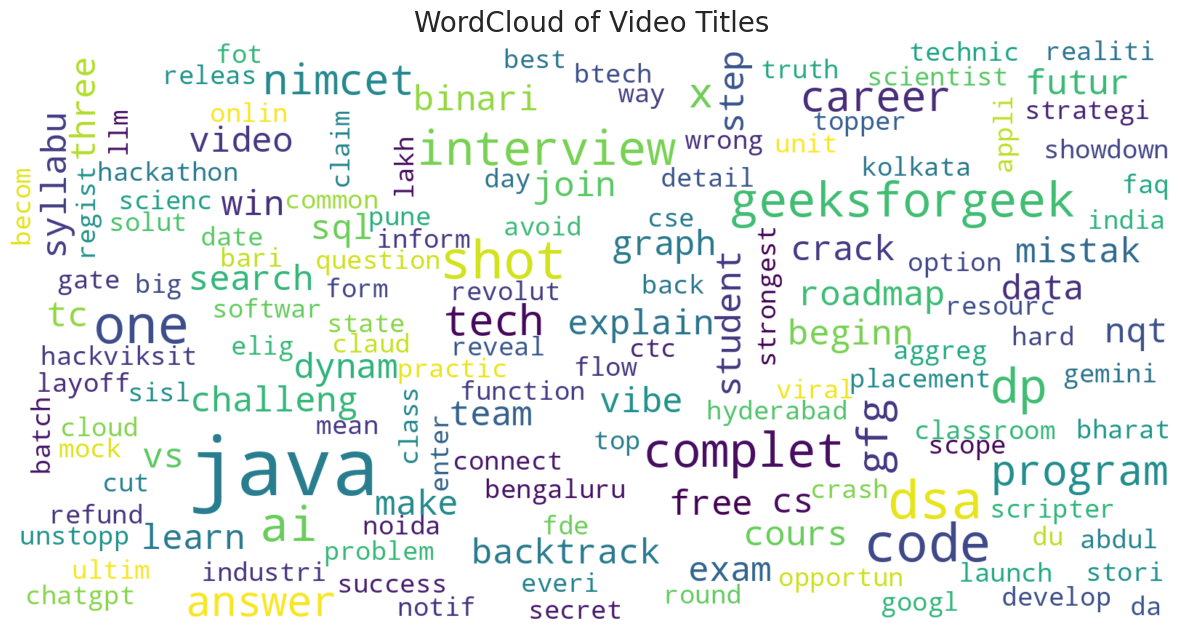

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

consolidated = ' '.join(word for word in data['Title'].astype(str))

wordCloud = WordCloud(
    width=1600,
    height=800,
    random_state=21,
    max_font_size=110,
    collocations=False,
    background_color='white'
)

plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Video Titles", fontsize=20)
plt.show()

# **2. Top 3 Most Viewed Videos**

A bar plot is used to display the top-performing videos based on view count. This visualization clearly shows which videos attract the most audience engagement.

/tmp/ipykernel_1063/1222352864.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


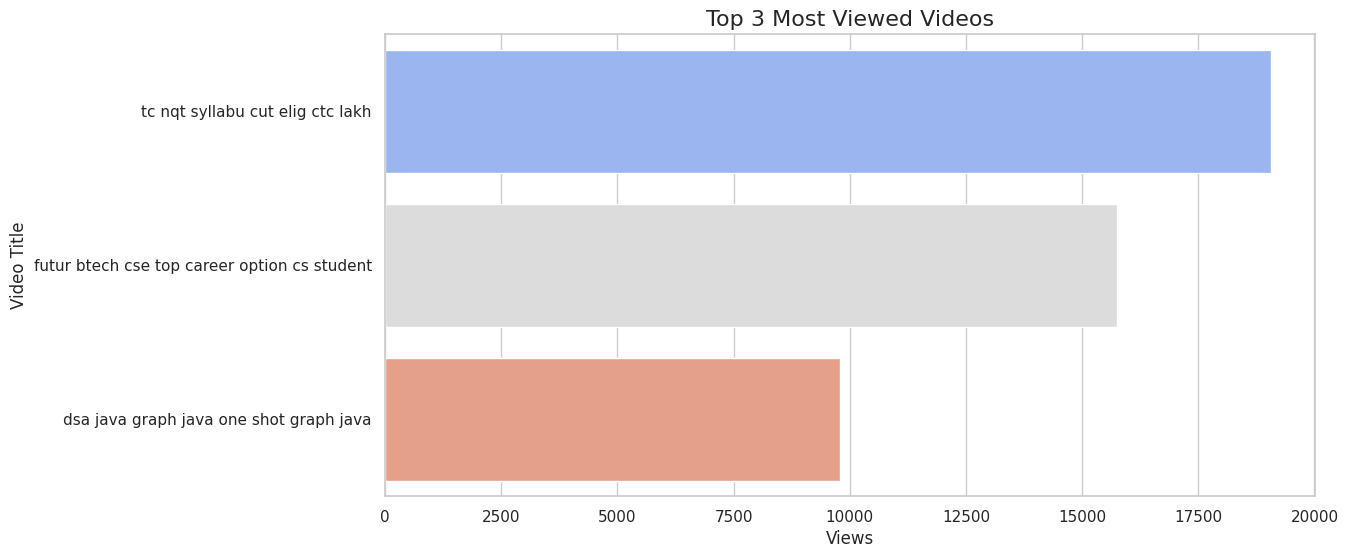

In [21]:
top_videos = data.sort_values(by='Views', ascending=False).head(3)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Views',
    y='Title',
    data=top_videos,
    palette='coolwarm'
)
plt.title("Top 3 Most Viewed Videos", fontsize=16)
plt.xlabel("Views")
plt.ylabel("Video Title")
plt.show()

# **3. Video Count by Duration Category**

A count plot visualizes the distribution of videos across different duration categories such as Mini-Videos, Long-Videos and Very-Long-Videos. This helps understand the type of content the channel focuses on.




/tmp/ipykernel_1063/4206731473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


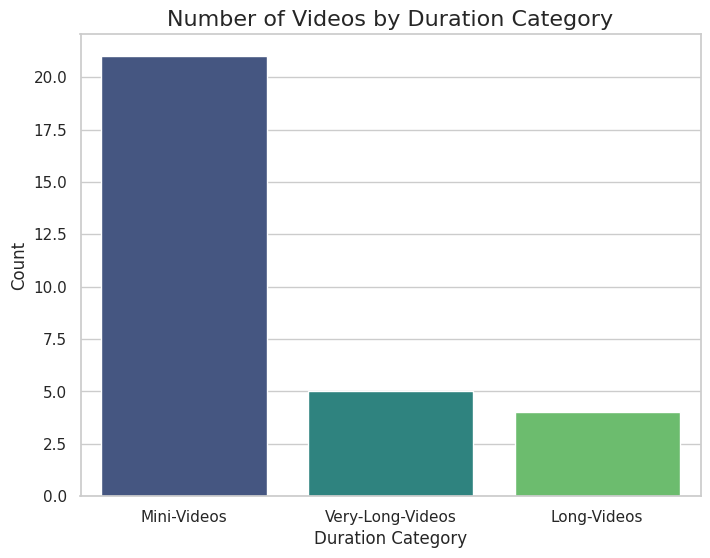

In [22]:
plt.figure(figsize=(8, 6))
sns.countplot(
    x='Duration',
    data=data,
    palette='viridis',
    order=data['Duration'].value_counts().index
)
plt.title("Number of Videos by Duration Category", fontsize=16)
plt.ylabel("Count")
plt.xlabel("Duration Category")
plt.show()